# Análisis de `HDBSCANVAL_COLLECTION.csv`

Notebook preparado para analizar de forma escalable campañas grandes de validación, incluyendo el caso de **97+3 observaciones**. El diseño evita figuras que dependan de leyendas extensas o ejes X saturados, priorizando distribuciones, rankings parciales, agregaciones y heatmaps compactos.


## Uso

1. Ejecuta `collect_hdbscanval_v1_1.py` sobre la raíz del dataset.
2. Verifica la ruta de `CSV_PATH` en la primera celda de código.
3. Ejecuta el notebook de arriba abajo.
4. Para el TFM, usa preferentemente las figuras globales, rankings Top-N y tablas resumidas.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["figure.dpi"] = 120

CSV_PATH = Path("../dataset/HDBSCANVAL_COLLECTION.csv")
TOP_N = 20
HEATMAP_MAX_ROWS = 60
FIG_WIDTH_WIDE = 12
FIG_HEIGHT_MEDIUM = 6
FIG_HEIGHT_TALL = 10
CSV_PATH

%matplotlib widget

In [2]:
df = pd.read_csv(CSV_PATH)
df.head()


,version,obs,object_name,inst,exposure,event_file,region_list,productcode,productcodeall,hdbscan_region_list,...,precision,recall,F1,median_match_arcsec,max_match_arcsec,duration_header,source_csv,source_obs_dir,collector_version,collector_row_index
0,v1.6,2940701,UGC4203,PN,3,E:\nxsa_AI\dataset\0002940701\pps\P0002940701P...,E:\nxsa_AI\dataset\0002940701\pps\P0002940701E...,0,1,E:\nxsa_AI\dataset\0002940701\pps\P0002940701E...,...,0.005814,0.105263,0.011019,2.071543,4.022607,8411.0,E:\nxsa_AI\dataset\0002940701\pps\P0002940701E...,2940701,v1.6,1
1,v1.6,2940701,UGC4203,PN,3,E:\nxsa_AI\dataset\0002940701\pps\P0002940701P...,E:\nxsa_AI\dataset\0002940701\pps\P0002940701E...,10,11,E:\nxsa_AI\dataset\0002940701\pps\P0002940701E...,...,0.005312,0.210526,0.010363,6.619945,14.011870,8411.0,E:\nxsa_AI\dataset\0002940701\pps\P0002940701E...,2940701,v1.6,1
2,v1.6,2940701,UGC4203,PN,3,E:\nxsa_AI\dataset\0002940701\pps\P0002940701P...,E:\nxsa_AI\dataset\0002940701\pps\P0002940701E...,20,21,E:\nxsa_AI\dataset\0002940701\pps\P0002940701E...,...,0.002874,0.157895,0.005644,4.205636,12.825802,8411.0,E:\nxsa_AI\dataset\0002940701\pps\P0002940701E...,2940701,v1.6,1
3,v1.6,2940701,UGC4203,PN,3,E:\nxsa_AI\dataset\0002940701\pps\P0002940701P...,E:\nxsa_AI\dataset\0002940701\pps\P0002940701E...,30,31,E:\nxsa_AI\dataset\0002940701\pps\P0002940701E...,...,0.006329,0.052632,0.011299,0.587035,0.587035,8411.0,E:\nxsa_AI\dataset\0002940701\pps\P0002940701E...,2940701,v1.6,1
4,v1.6,7422201,Galactic Plane 22,PN,3,E:\nxsa_AI\dataset\0007422201\pps\P0007422201P...,E:\nxsa_AI\dataset\0007422201\pps\P0007422201E...,0,1,E:\nxsa_AI\dataset\0007422201\pps\P0007422201E...,...,0.176471,0.292683,0.220183,7.376383,14.893318,12276.0,E:\nxsa_AI\dataset\0007422201\pps\P0007422201E...,7422201,v1.6,1


In [3]:
numeric_cols = [
    "precision", "recall", "F1", "retained_fraction", "accepted_clusters",
    "raw_clusters", "TP", "FP", "FN", "median_match_arcsec", "max_match_arcsec"
]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

if "obs" in df.columns:
    df["obs"] = df["obs"].astype(str)
if "object_name" in df.columns:
    df["object_name"] = df["object_name"].fillna("<sin_nombre>")
if "hyperparameter_profile" in df.columns:
    df["hyperparameter_profile"] = df["hyperparameter_profile"].fillna("<sin_perfil>")
if "version" in df.columns:
    df["version"] = df["version"].fillna("<sin_version>")

df.shape


(400, 51)

## Resumen global


In [4]:
summary = pd.DataFrame({
    "n_rows": [len(df)],
    "n_obs": [df["obs"].nunique() if "obs" in df.columns else np.nan],
    "mean_precision": [df["precision"].mean() if "precision" in df.columns else np.nan],
    "mean_recall": [df["recall"].mean() if "recall" in df.columns else np.nan],
    "mean_F1": [df["F1"].mean() if "F1" in df.columns else np.nan],
    "median_F1": [df["F1"].median() if "F1" in df.columns else np.nan],
    "median_match_arcsec": [df["median_match_arcsec"].median() if "median_match_arcsec" in df.columns else np.nan],
})
summary


,n_rows,n_obs,mean_precision,mean_recall,mean_F1,median_F1,median_match_arcsec
0,400,100,0.220002,0.253887,0.203022,0.189304,3.347068


## Tabla por observación


In [5]:
group_cols = [c for c in ["obs", "object_name", "detection_mode", "hyperparameter_profile", "version"] if c in df.columns]
metric_cols = [c for c in ["precision", "recall", "F1", "retained_fraction", "accepted_clusters", "TP", "FP", "FN", "median_match_arcsec"] if c in df.columns]
agg_map = {c: "mean" for c in metric_cols}
per_obs = df.groupby(group_cols, dropna=False).agg(agg_map).reset_index() if group_cols else df.copy()
if {"F1", "precision", "recall"}.issubset(per_obs.columns):
    per_obs = per_obs.sort_values(["F1", "precision", "recall"], ascending=False, na_position="last")
per_obs.head(TOP_N)


,obs,object_name,detection_mode,hyperparameter_profile,version,precision,recall,F1,retained_fraction,accepted_clusters,TP,FP,FN,median_match_arcsec
126,405320501,M31,spatiotemporal,Brecallplus,v1.6,0.847826,0.450867,0.588679,0.278848,92.0,78.0,14.0,95.0,1.584116
124,405320501,M31,spatiotemporal,Bbalanced,v1.6,0.778846,0.468208,0.584838,0.278848,104.0,81.0,23.0,92.0,1.297443
342,81341101,IRAS15250+36,spatiotemporal,Brecallplus,v1.6,0.666667,0.517647,0.582781,0.939307,66.0,44.0,22.0,41.0,4.292044
340,81341101,IRAS15250+36,spatiotemporal,Bbalanced,v1.6,0.520408,0.600000,0.557377,0.939307,98.0,51.0,47.0,34.0,4.764422
125,405320501,M31,spatiotemporal,Bprecision,v1.6,0.839506,0.393064,0.535433,0.278848,81.0,68.0,13.0,105.0,1.724044
127,405320501,M31,spatiotemporal,Brecallpp,v1.6,0.569536,0.497110,0.530864,0.278848,151.0,86.0,65.0,87.0,1.644000
14,112800201,NGC 300,spatiotemporal,Brecallplus,v1.6,0.682927,0.434109,0.530806,0.573805,82.0,56.0,26.0,73.0,3.457968
343,81341101,IRAS15250+36,spatiotemporal,Brecallpp,v1.6,0.409396,0.717647,0.521368,0.939307,149.0,61.0,88.0,24.0,3.993713
187,61940901,122-013,spatiotemporal,Brecallpp,v1.6,0.475000,0.575758,0.520548,0.023786,40.0,19.0,21.0,14.0,3.230235
12,112800201,NGC 300,spatiotemporal,Bbalanced,v1.6,0.492958,0.542636,0.516605,0.573805,142.0,70.0,72.0,59.0,2.689715


## Gráficas escalables


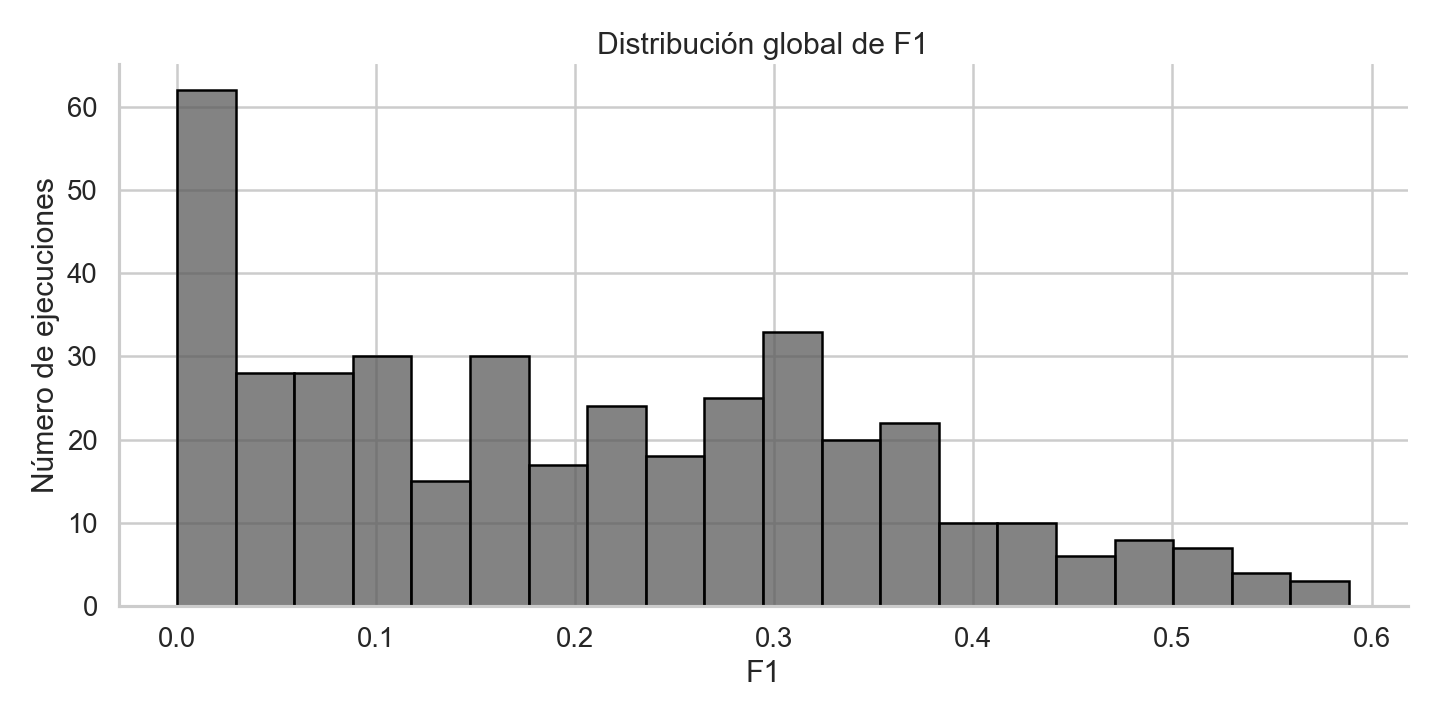

In [6]:
if "F1" in df.columns:
    plt.figure(figsize=(FIG_WIDTH_WIDE, FIG_HEIGHT_MEDIUM))
    sns.histplot(df["F1"].dropna(), bins=20, color="0.35", edgecolor="black")
    plt.xlabel("F1")
    plt.ylabel("Número de ejecuciones")
    plt.title("Distribución global de F1")
    plt.tight_layout()
    plt.show()


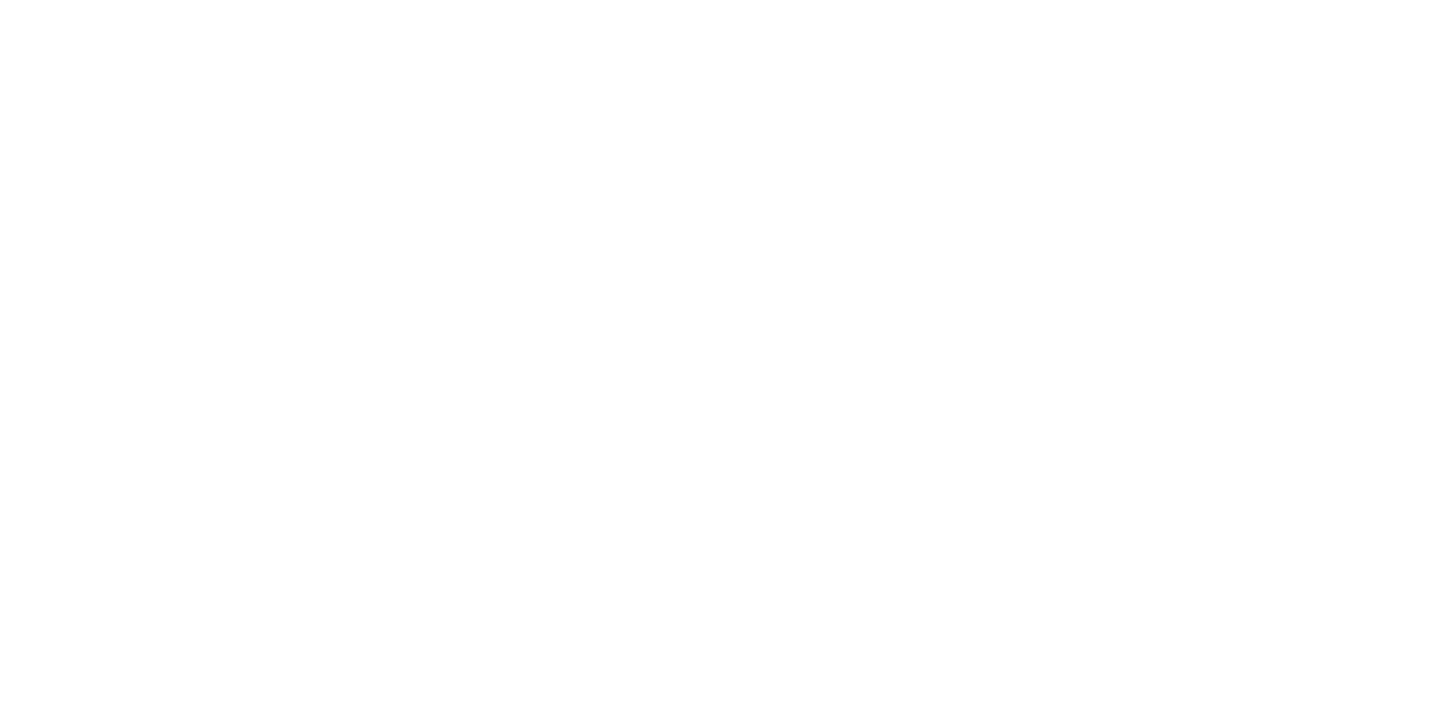

In [7]:
if {"precision", "recall"}.issubset(df.columns):
    plt.figure(figsize=(FIG_WIDTH_WIDE, FIG_HEIGHT_MEDIUM))
    plt.scatter(df["recall"], df["precision"], s=35, c="black", alpha=0.7)
    plt.xlabel("Recall")
    plt.ylabel("Precisión")
    plt.title("Precisión frente a recall")
    plt.tight_layout()
    plt.show()


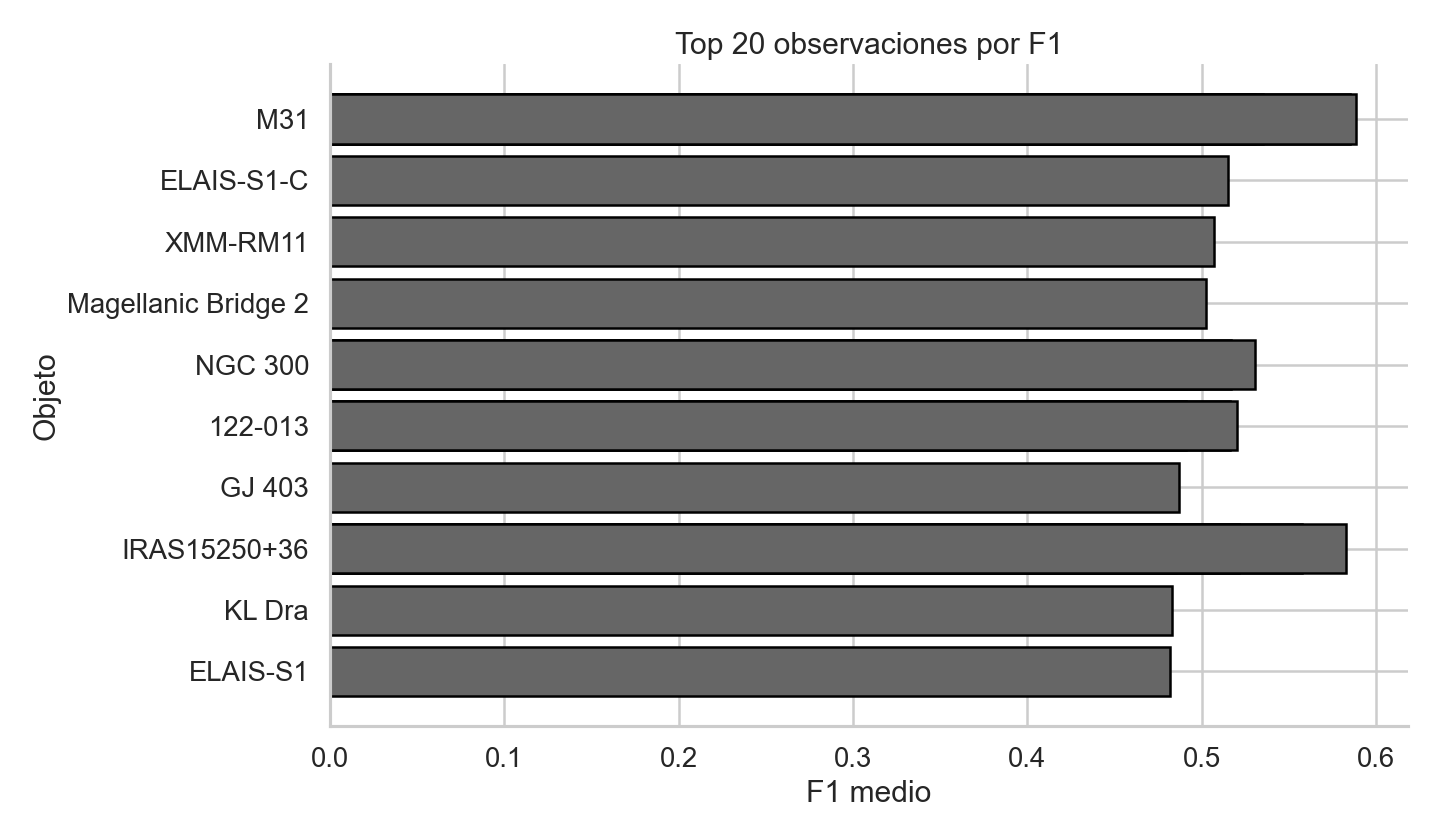

In [8]:
if {"object_name", "F1"}.issubset(per_obs.columns):
    top_obs = per_obs.nlargest(min(TOP_N, len(per_obs)), "F1").copy()
    top_obs = top_obs.sort_values("F1", ascending=True)
    plt.figure(figsize=(FIG_WIDTH_WIDE, max(6, 0.35 * len(top_obs))))
    plt.barh(top_obs["object_name"].astype(str), top_obs["F1"], color="0.4", edgecolor="black")
    plt.xlabel("F1 medio")
    plt.ylabel("Objeto")
    plt.title(f"Top {min(TOP_N, len(top_obs))} observaciones por F1")
    plt.tight_layout()
    plt.show()


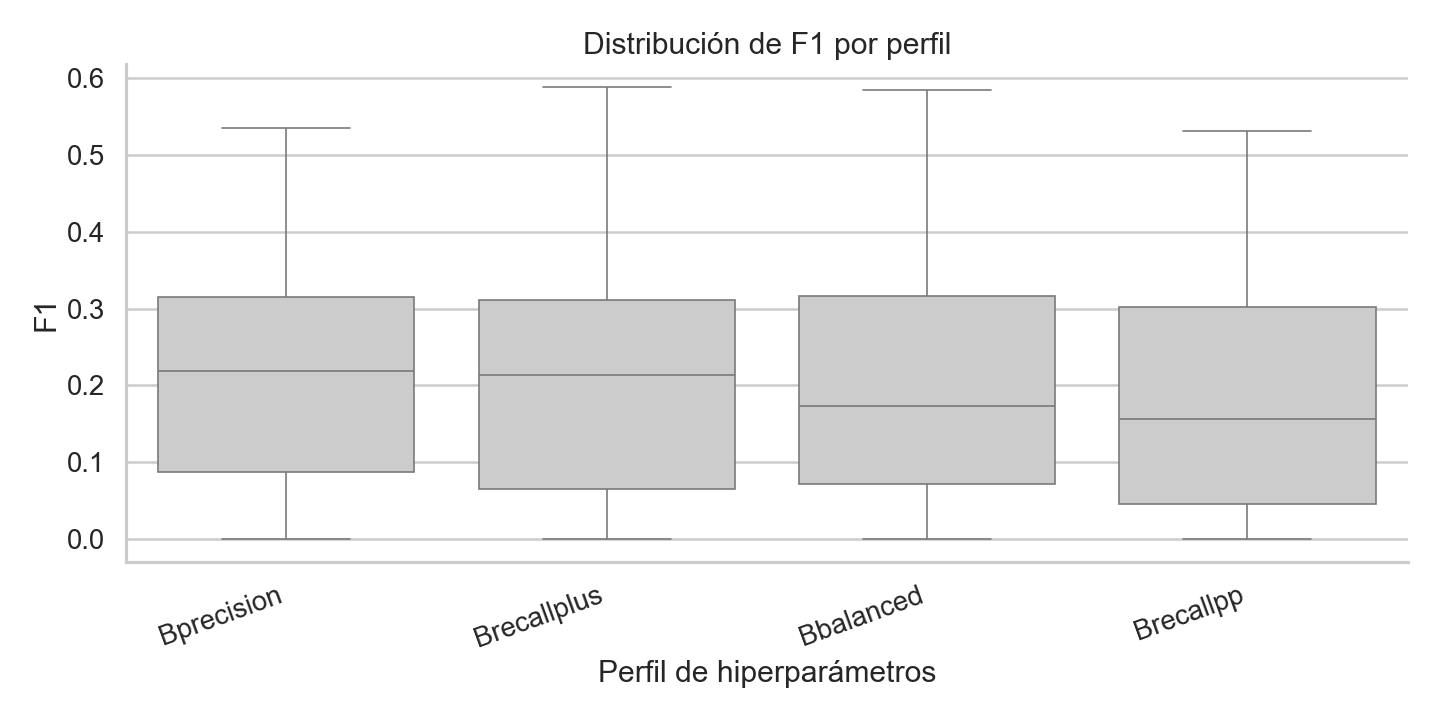

In [9]:
if {"hyperparameter_profile", "F1"}.issubset(df.columns):
    plt.figure(figsize=(FIG_WIDTH_WIDE, FIG_HEIGHT_MEDIUM))
    order = df.groupby("hyperparameter_profile")["F1"].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x="hyperparameter_profile", y="F1", order=order, color="0.8")
    plt.xlabel("Perfil de hiperparámetros")
    plt.ylabel("F1")
    plt.title("Distribución de F1 por perfil")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()


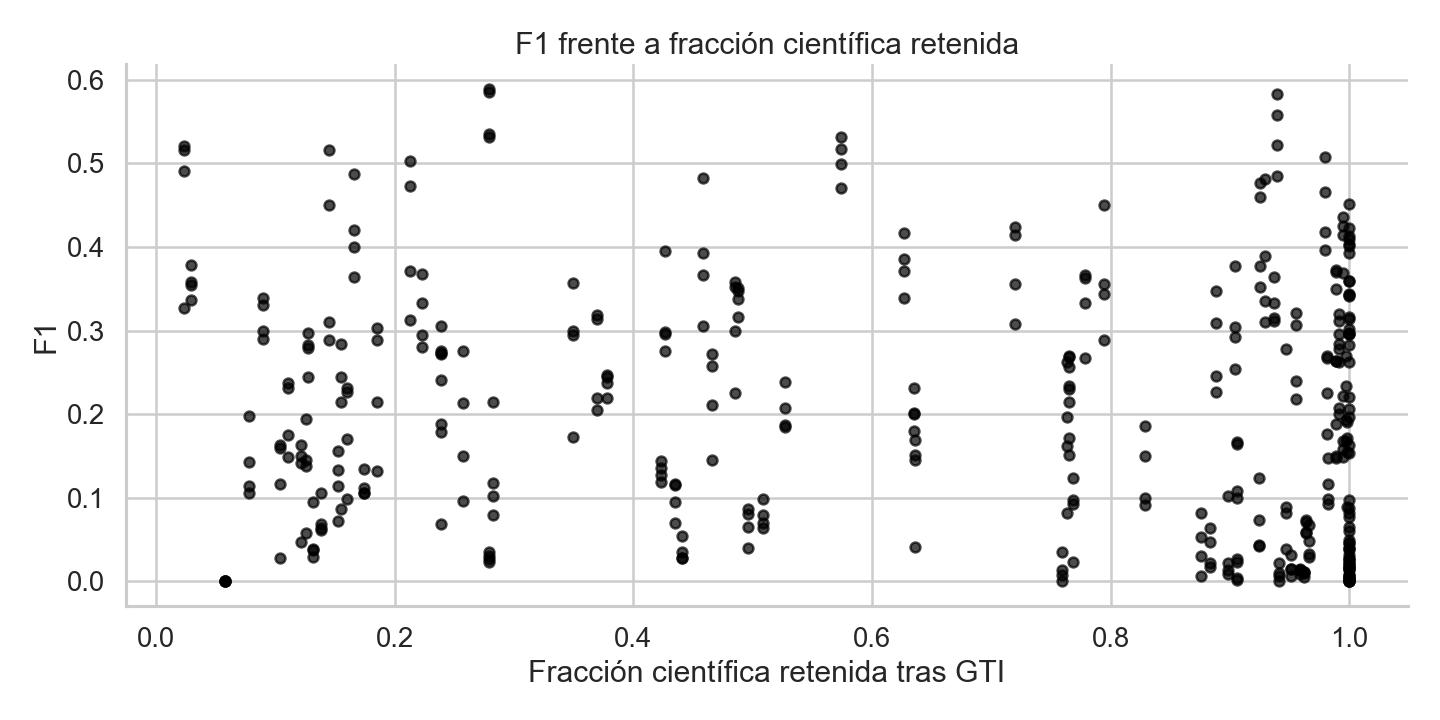

In [10]:
if {"retained_fraction", "F1"}.issubset(df.columns):
    plt.figure(figsize=(FIG_WIDTH_WIDE, FIG_HEIGHT_MEDIUM))
    plt.scatter(df["retained_fraction"], df["F1"], s=35, c="black", alpha=0.7)
    plt.xlabel("Fracción científica retenida tras GTI")
    plt.ylabel("F1")
    plt.title("F1 frente a fracción científica retenida")
    plt.tight_layout()
    plt.show()


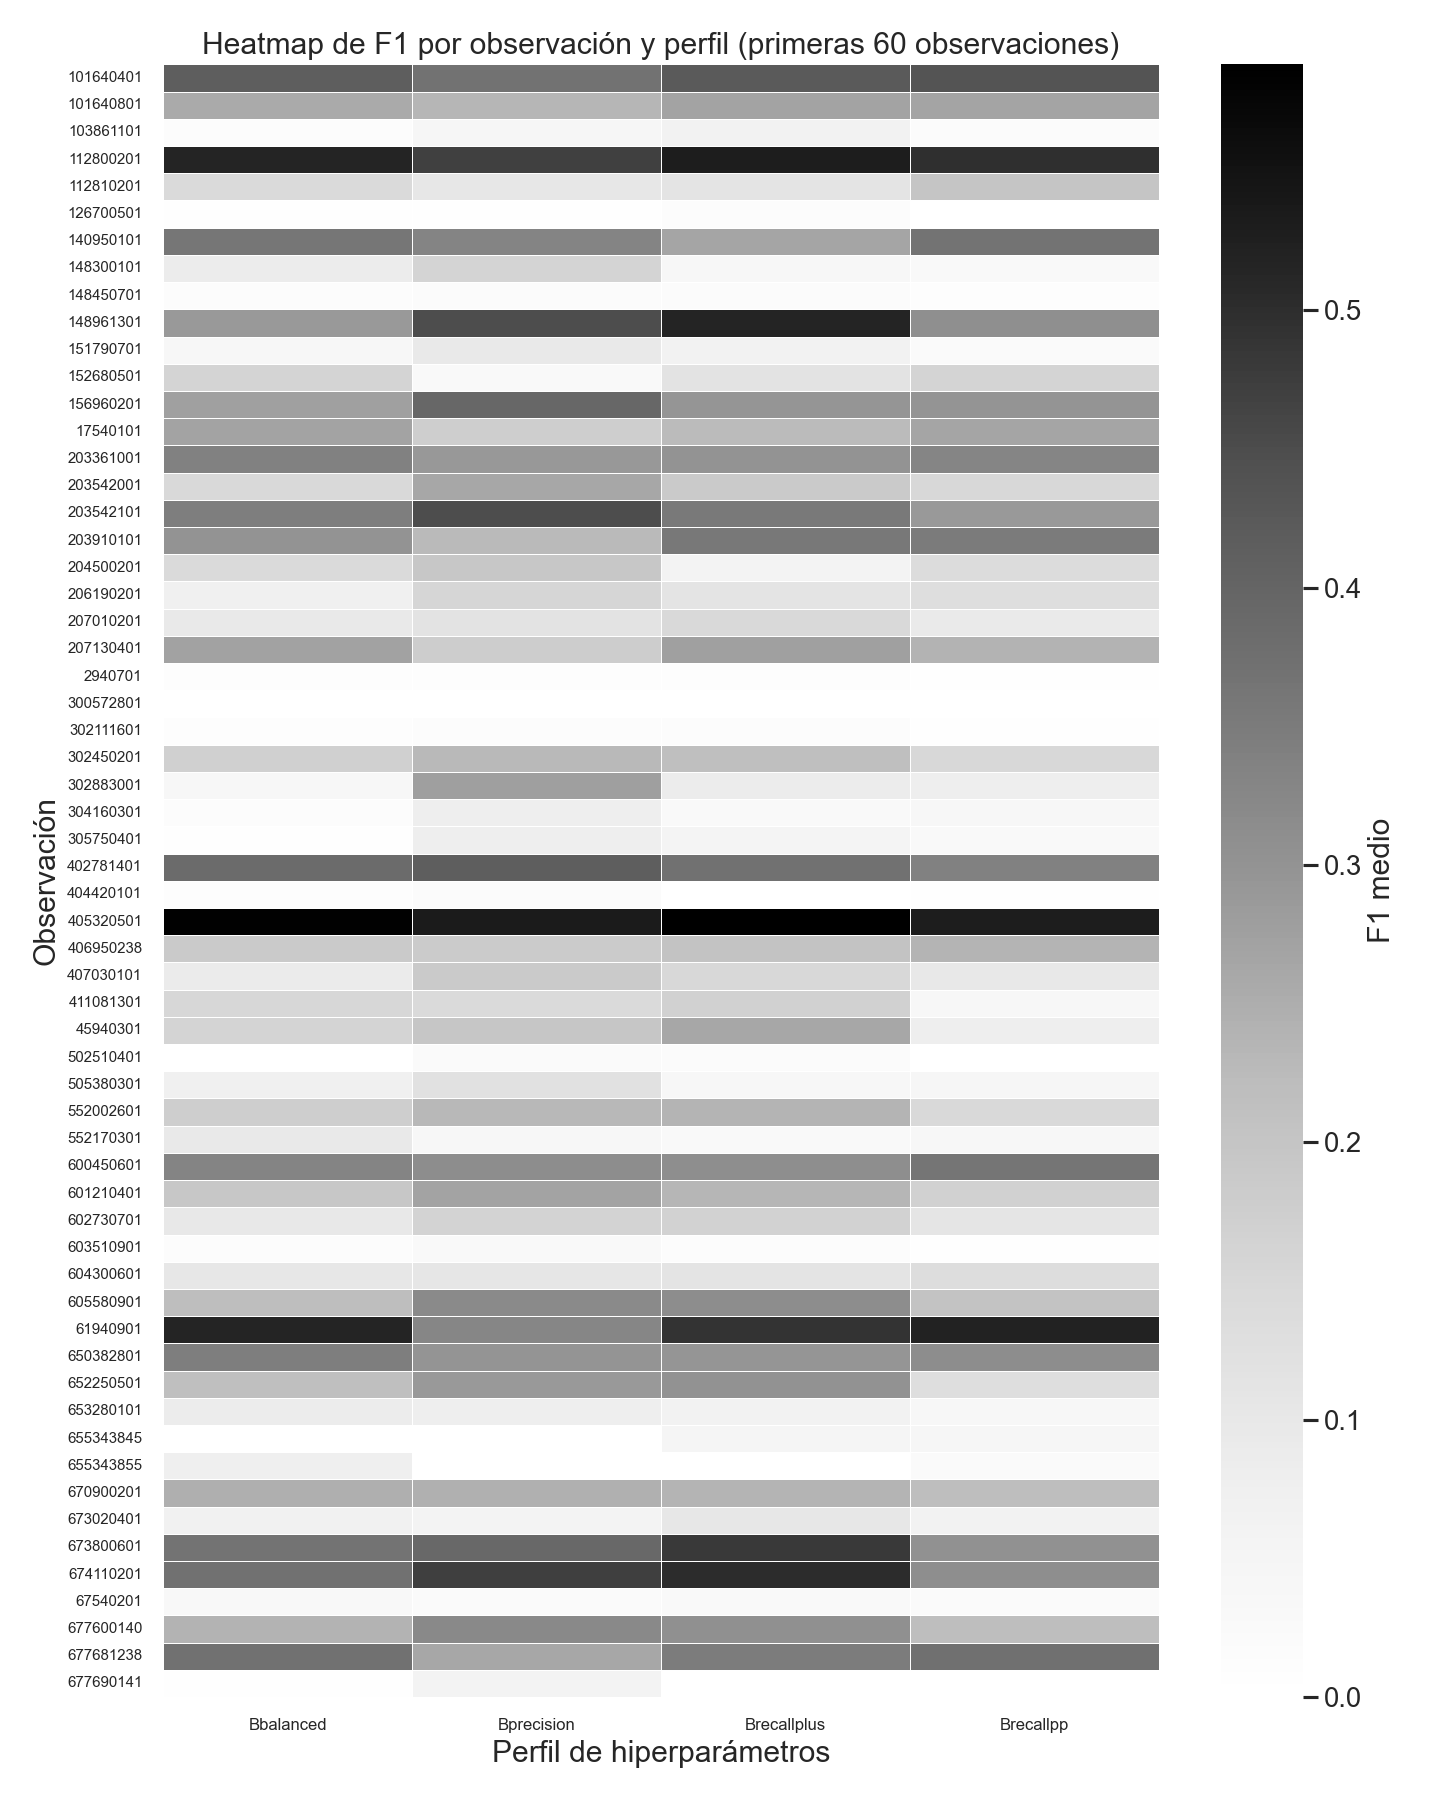

In [11]:
if {"obs", "hyperparameter_profile", "F1"}.issubset(df.columns):
    heatmap_df = df.pivot_table(index="obs", columns="hyperparameter_profile",
                                values="F1", aggfunc="mean")
    heatmap_df = heatmap_df.sort_index()
    if len(heatmap_df) > HEATMAP_MAX_ROWS:
        heatmap_df = heatmap_df.iloc[:HEATMAP_MAX_ROWS]

    plt.figure(figsize=(FIG_WIDTH_WIDE, max(6, 0.25 * len(heatmap_df))))
    ax = sns.heatmap(
        heatmap_df,
        cmap="Greys",
        linewidths=0.3,
        linecolor="white",
        cbar_kws={"label": "F1 medio"},
        yticklabels=1
    )
    ax.tick_params(axis="y", labelsize=9)
    ax.tick_params(axis="x", labelsize=10)
    plt.xlabel("Perfil de hiperparámetros")
    plt.ylabel("Observación")
    plt.title(f"Heatmap de F1 por observación y perfil (primeras {len(heatmap_df)} observaciones)")
    plt.tight_layout()
    plt.show()

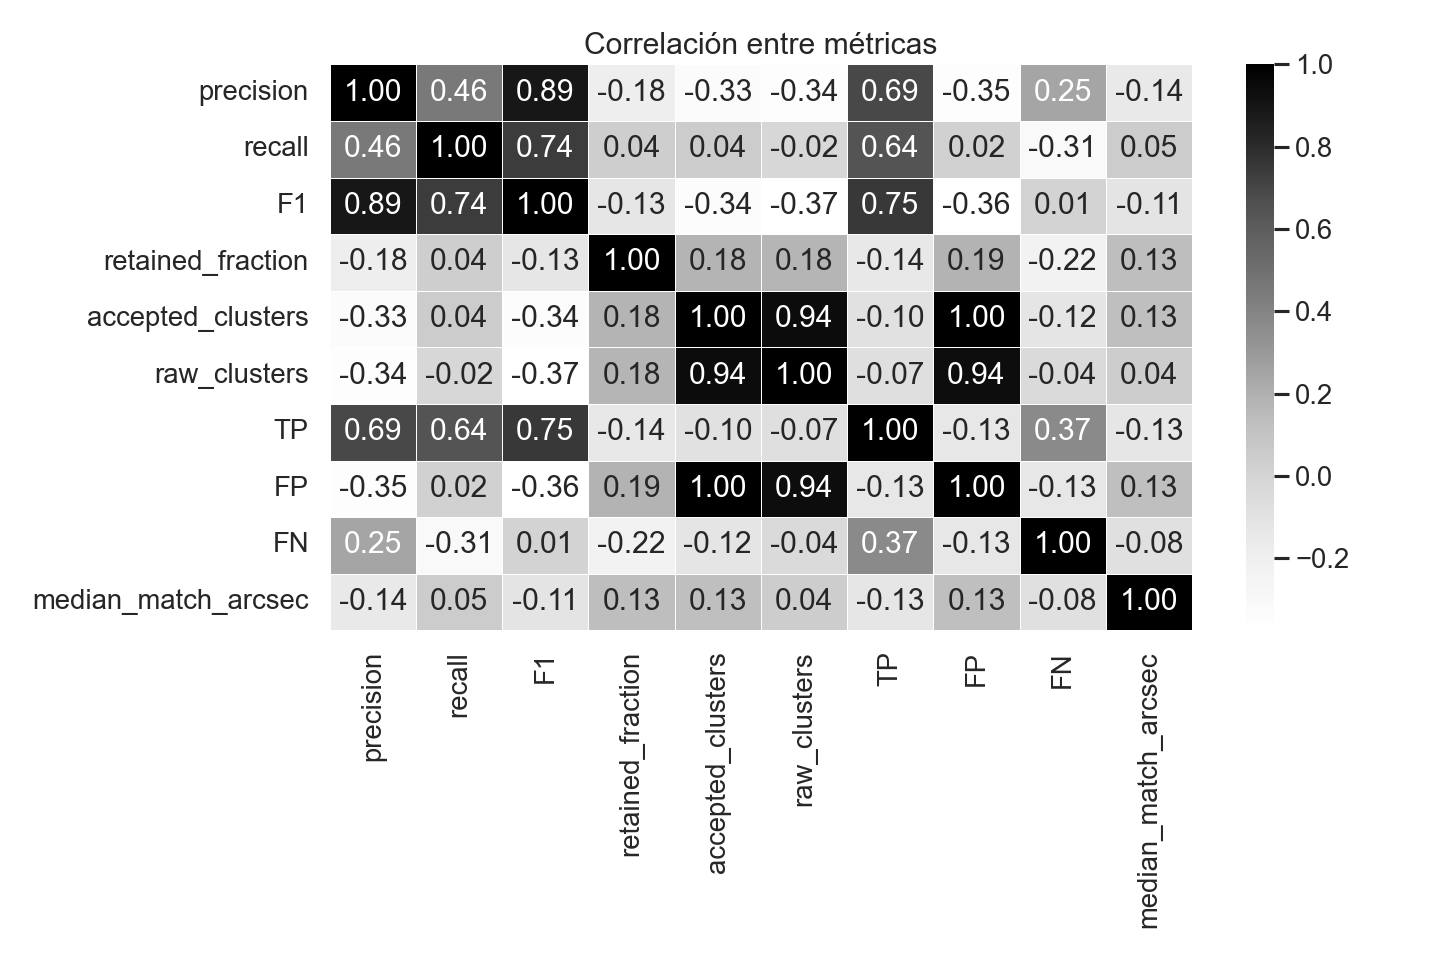

In [12]:
corr_cols = [c for c in ["precision", "recall", "F1", "retained_fraction", "accepted_clusters", "raw_clusters", "TP", "FP", "FN", "median_match_arcsec"] if c in df.columns]
if len(corr_cols) >= 2:
    corr = df[corr_cols].corr(numeric_only=True)
    plt.figure(figsize=(FIG_WIDTH_WIDE, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="Greys", linewidths=0.5, linecolor="white")
    plt.title("Correlación entre métricas")
    plt.tight_layout()
    plt.show()


## Conclusiones automáticas preliminares


In [13]:
conclusions = []

if "F1" in df.columns:
    conclusions.append(f"F1 medio global: {df['F1'].mean():.3f}")
    conclusions.append(f"F1 mediano global: {df['F1'].median():.3f}")
if {"precision", "recall"}.issubset(df.columns):
    conclusions.append(f"Precisión media global: {df['precision'].mean():.3f}")
    conclusions.append(f"Recall medio global: {df['recall'].mean():.3f}")
if {"object_name", "F1"}.issubset(per_obs.columns) and len(per_obs) > 0:
    best_row = per_obs.sort_values("F1", ascending=False).iloc[0]
    conclusions.append(f"Mejor observación por F1: {best_row['object_name']} (OBS {best_row['obs']}) con F1={best_row['F1']:.3f}")
if {"hyperparameter_profile", "F1"}.issubset(df.columns):
    profile_rank = df.groupby("hyperparameter_profile")["F1"].mean().sort_values(ascending=False)
    if len(profile_rank) > 0:
        conclusions.append(f"Perfil con mayor F1 medio: {profile_rank.index[0]} ({profile_rank.iloc[0]:.3f})")
if "median_match_arcsec" in df.columns:
    conclusions.append(f"Mediana global de distancias de matching: {df['median_match_arcsec'].median():.2f} arcsec")

for line in conclusions:
    print('-', line)


- F1 medio global: 0.203
- F1 mediano global: 0.189
- Precisión media global: 0.220
- Recall medio global: 0.254
- Mejor observación por F1: M31 (OBS 405320501) con F1=0.589
- Perfil con mayor F1 medio: Brecallplus (0.216)
- Mediana global de distancias de matching: 3.35 arcsec
